In [ ]:
# Import packages
from pathlib import Path
from XvP_utils import plotting

ANALYSIS_NAME = "Analysis_5"
ctx = plotting.notebook_context(ANALYSIS_NAME)
PROJECT_DIR = ctx.project_dir
SPECIES = ctx.species
INDEX_DIR = ctx.index_dir
ANALYSIS_DIR = Path.cwd()
CUTOFFS = ctx.knee('sampled', ['10x', 'polyT', 'randO', 'parse'])
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


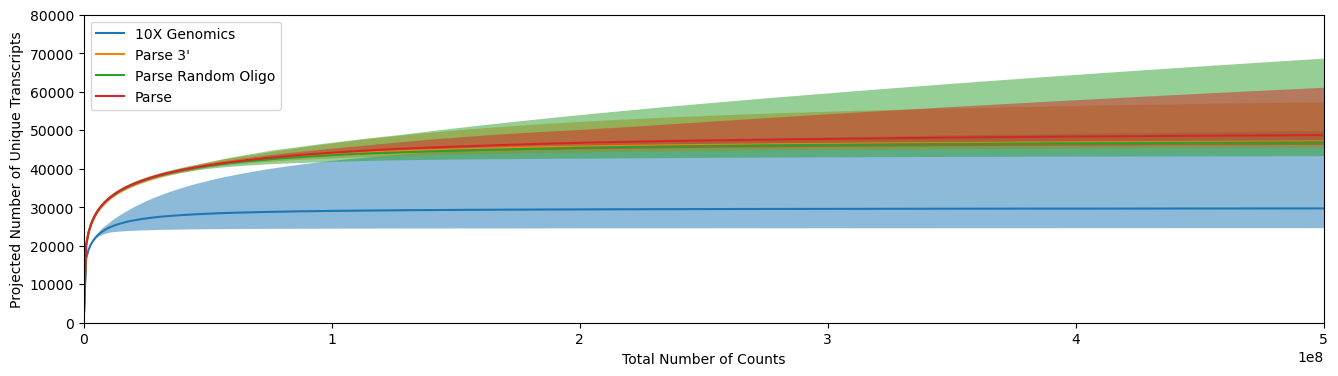

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

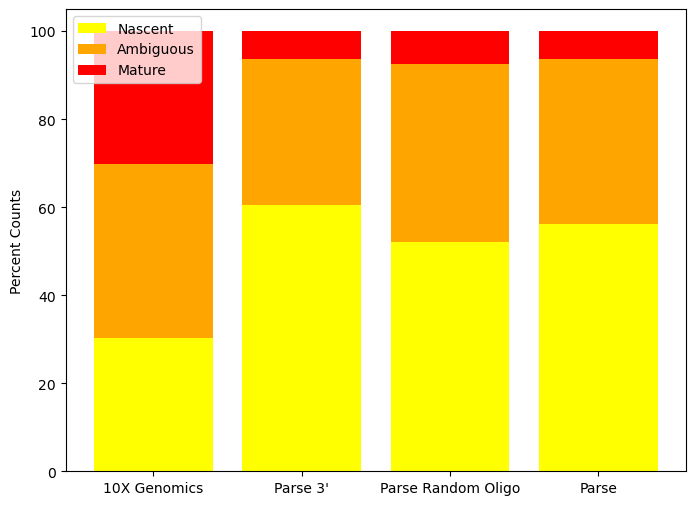

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

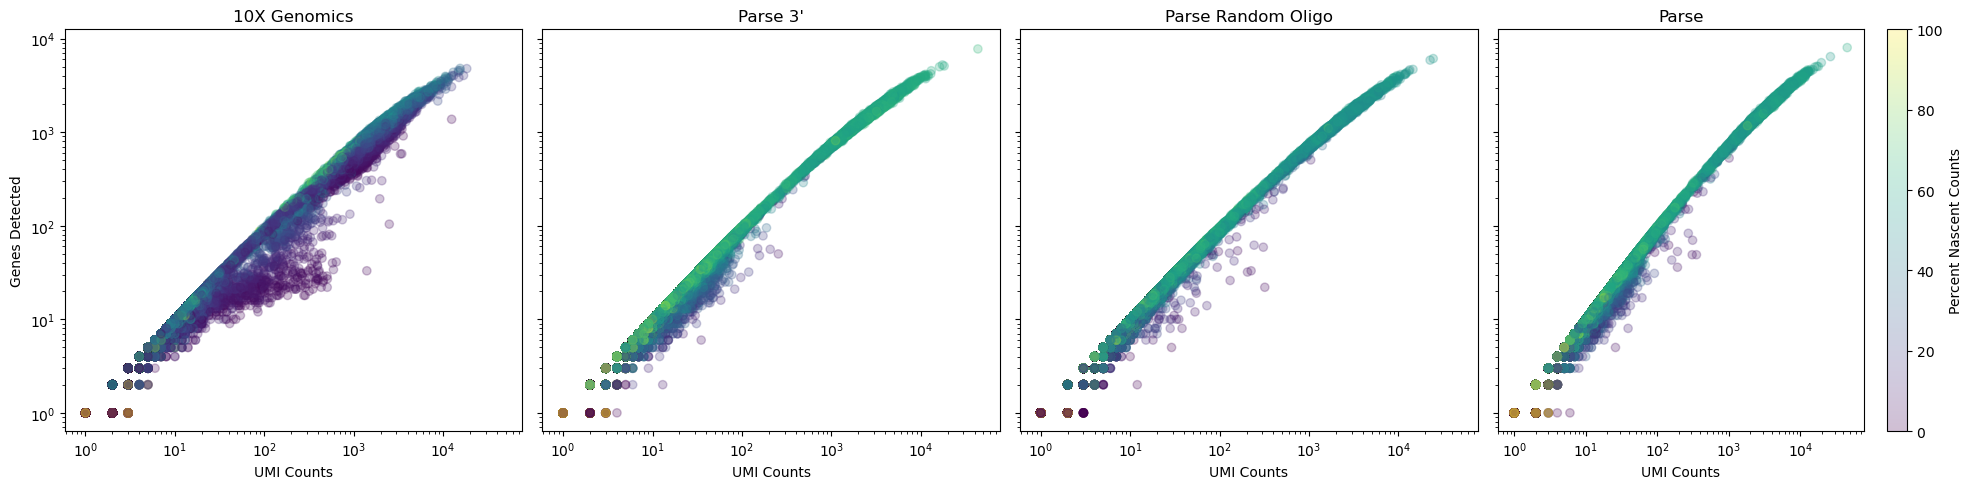

In [8]:
plotting.scatter_reads(raw_datasets)

In [ ]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=False)

In [11]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


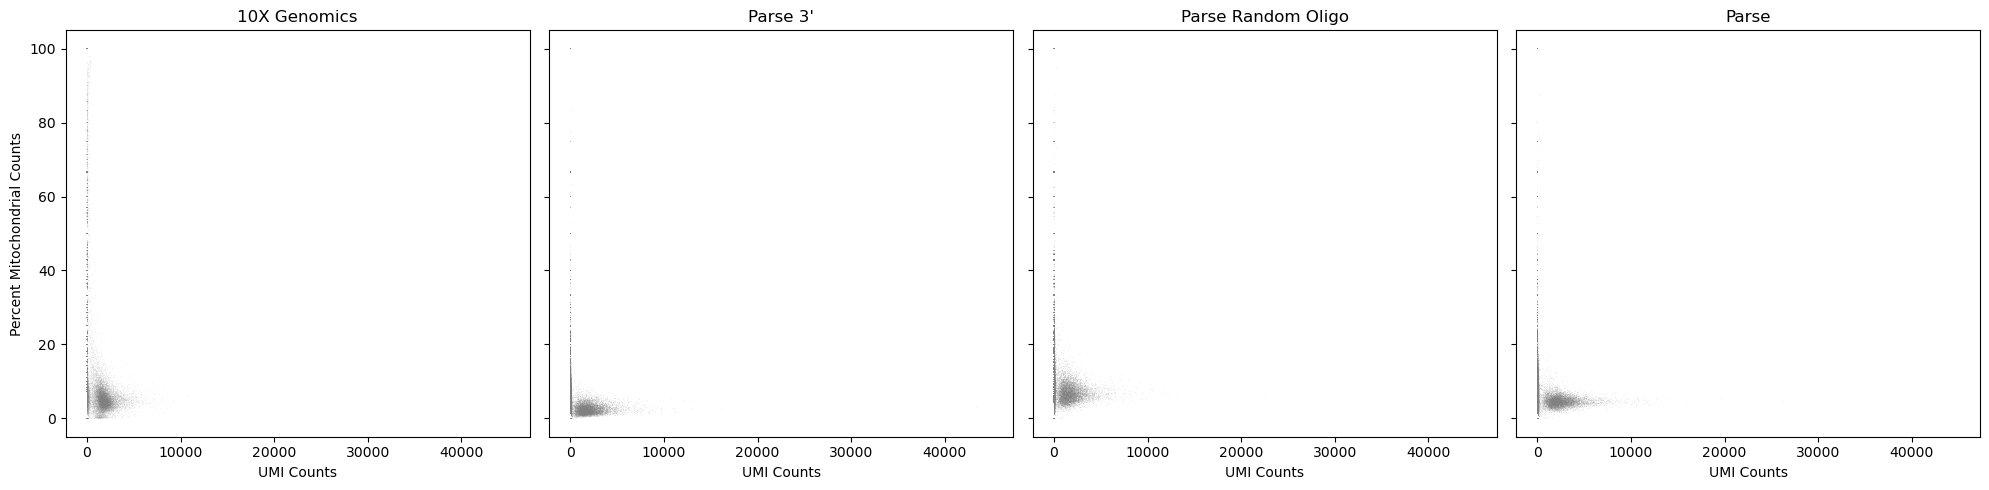

In [12]:
plotting.mito_scatter(raw_datasets)

17,155 cells passed the 300 UMI threshold for 10X Genomics
8,148 cells passed the 300 UMI threshold for Parse 3'
8,103 cells passed the 300 UMI threshold for Parse Random Oligo
8,202 cells passed the 300 UMI threshold for Parse


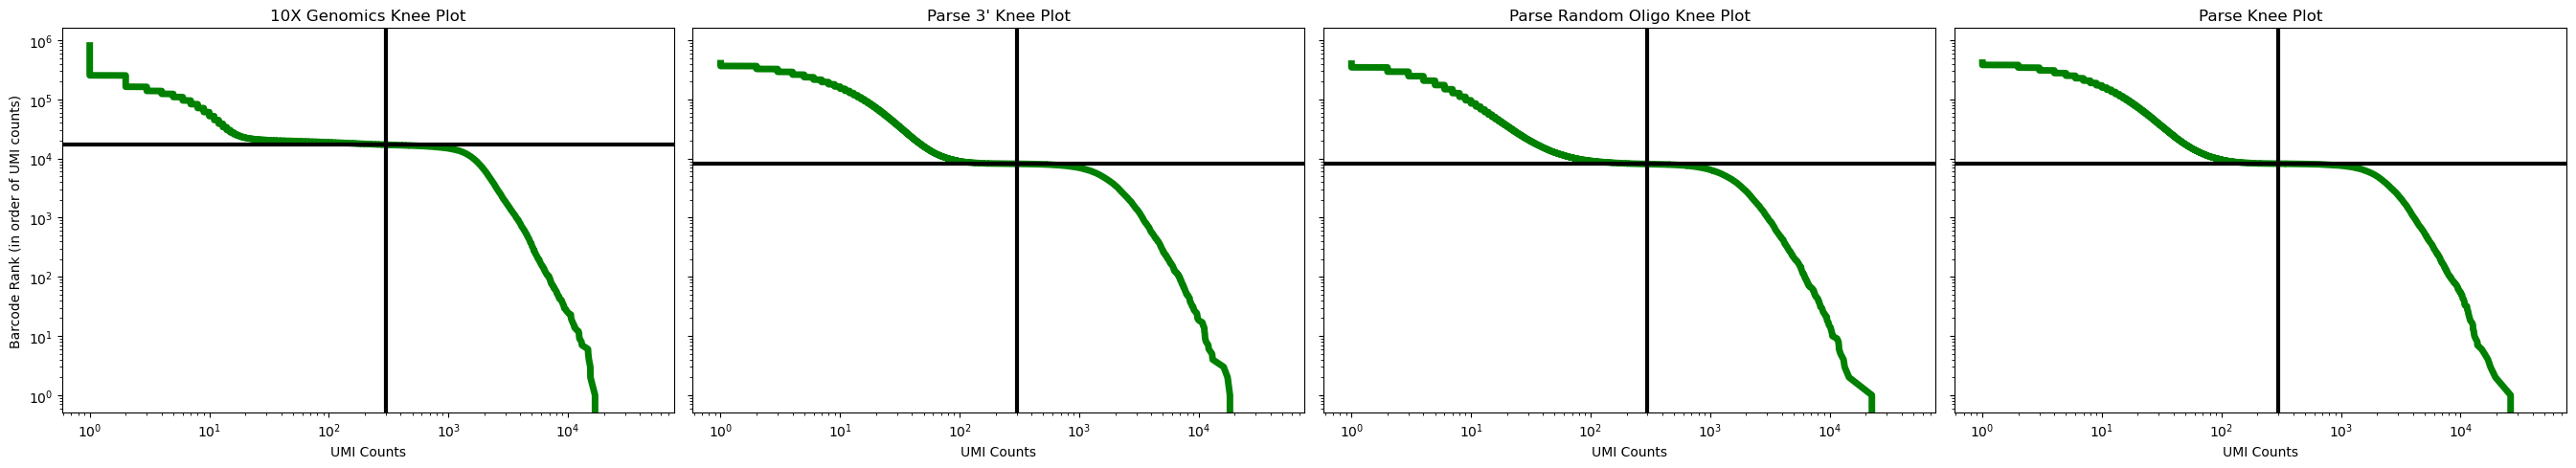

In [13]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS)

In [14]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

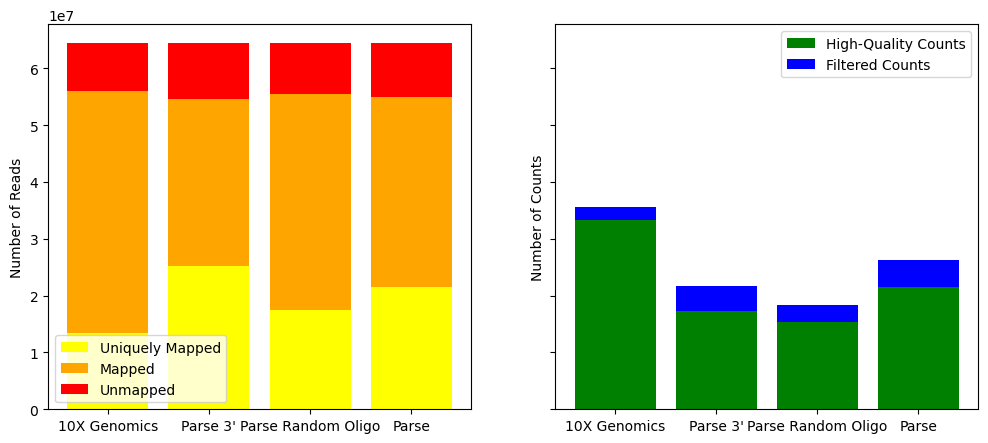

In [15]:
plotting.plot_filtering_metrics(datasets)

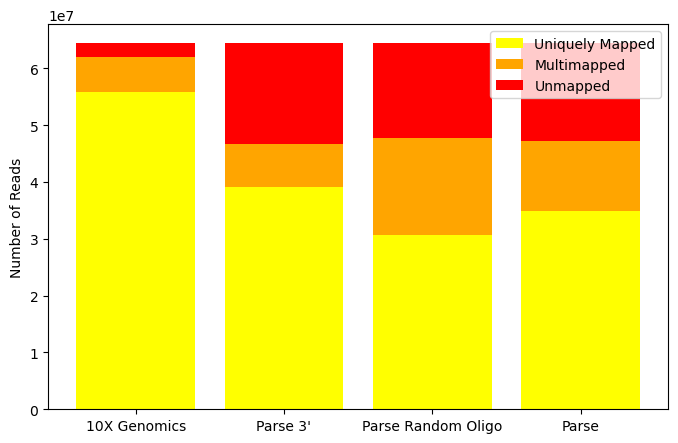

In [16]:
plotting.plot_filtering_metrics_star(datasets)

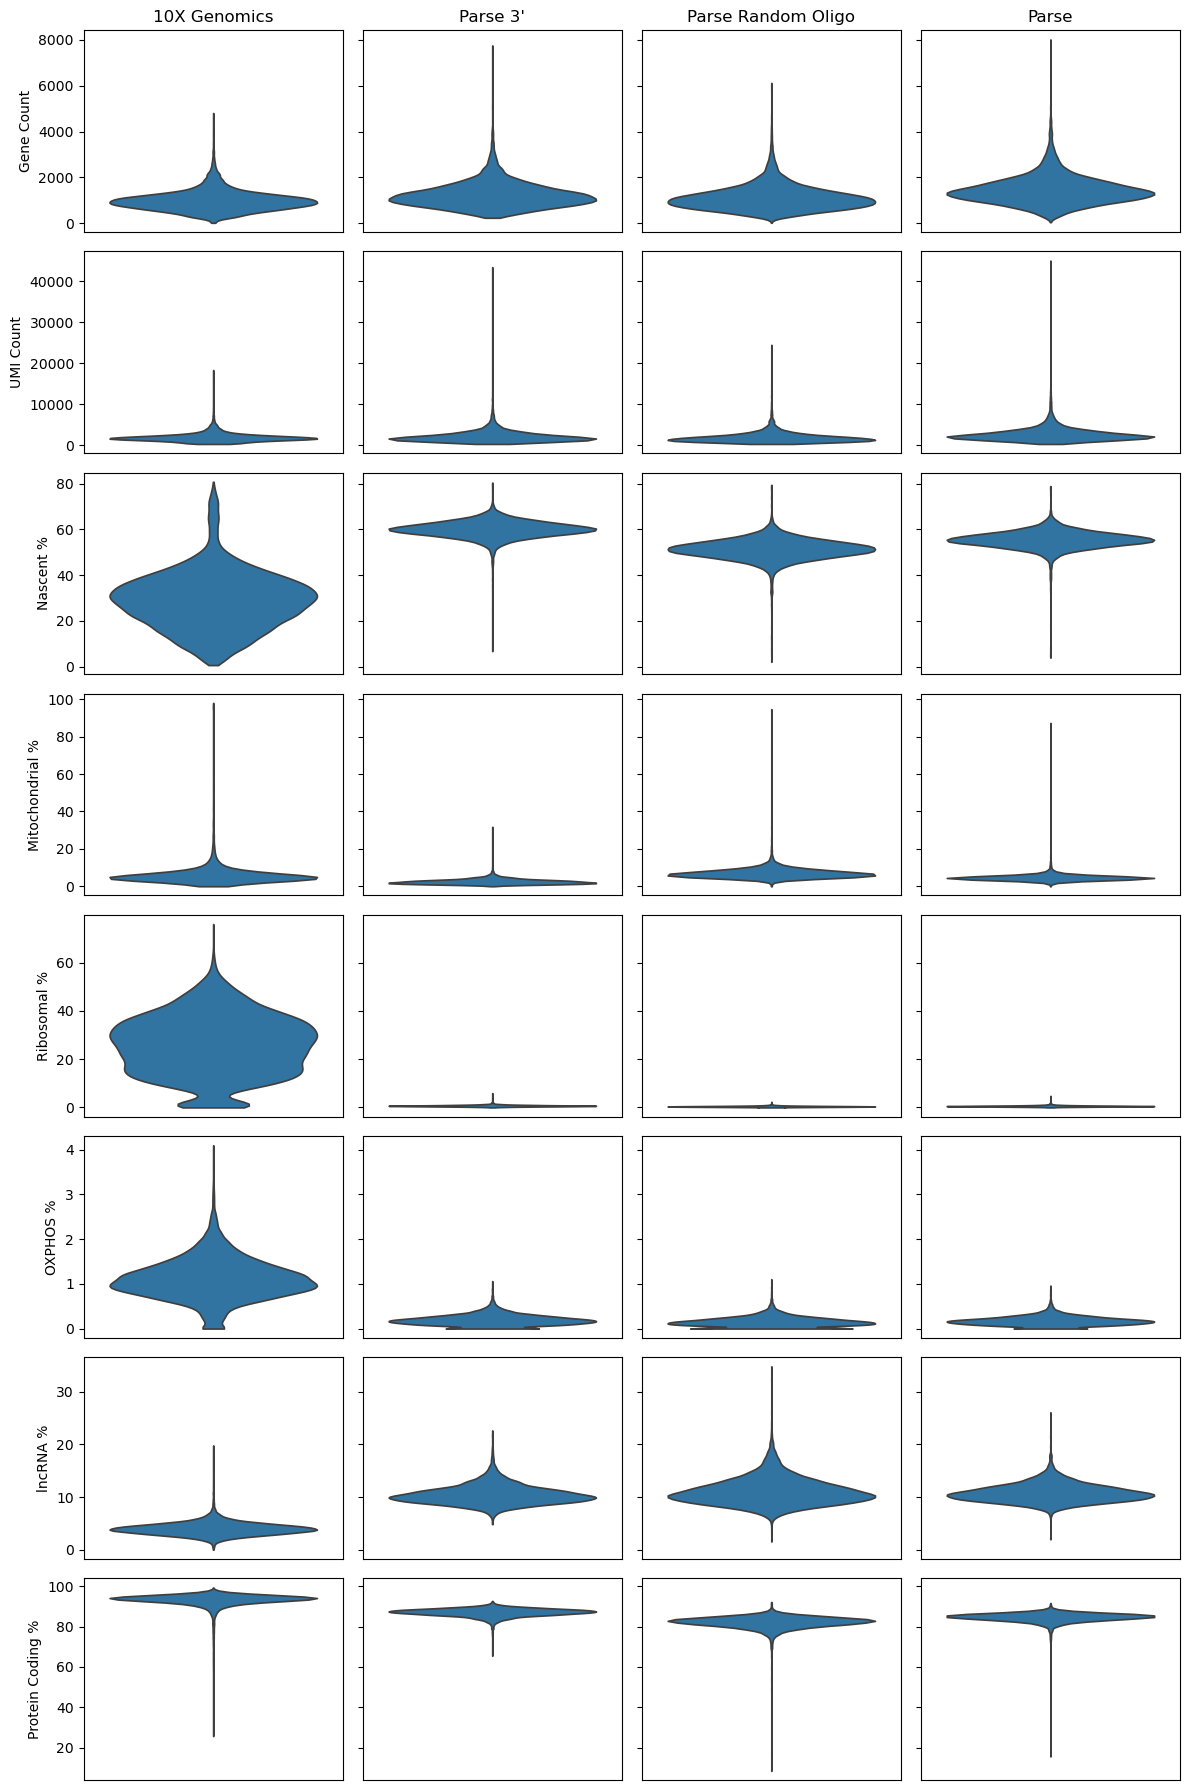

In [18]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_oxphos', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'OXPHOS %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

# Read/Gene Comparisons

In [ ]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G', 'CD3E', 'CD4', 'CD8A', 'CD8B']

B_marker_names = ['CD19', 'CD24', 'CD40', 'CD72']

NK_marker_names = ['FCGR3A', 'FCGR3B', 'NCAM1']

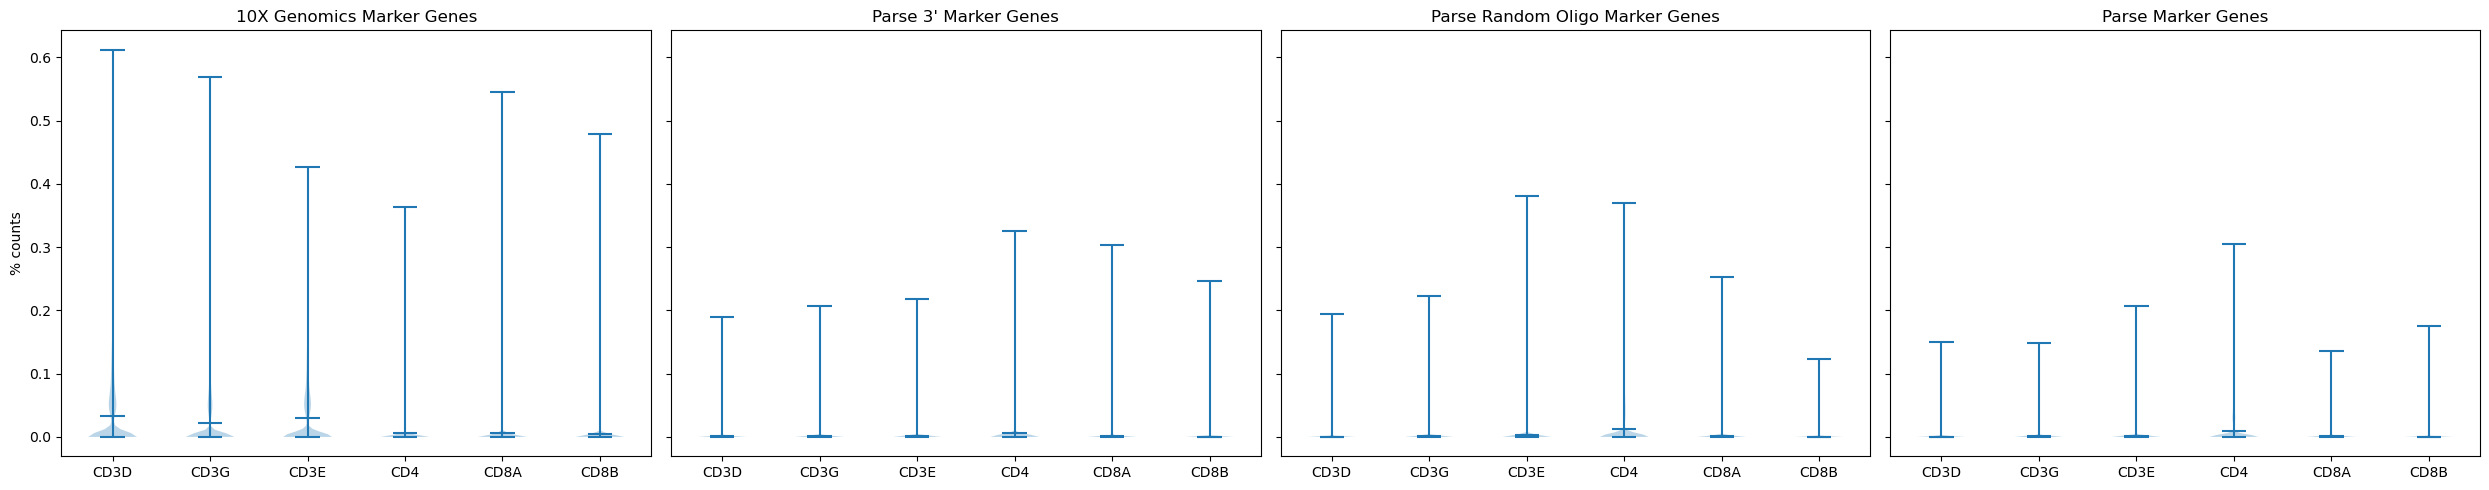

In [18]:
plotting.marker_genes(datasets, T_marker_names)

In [ ]:
plotting.marker_genes(datasets, B_marker_names)

In [ ]:
plotting.marker_genes(datasets, NK_marker_names)

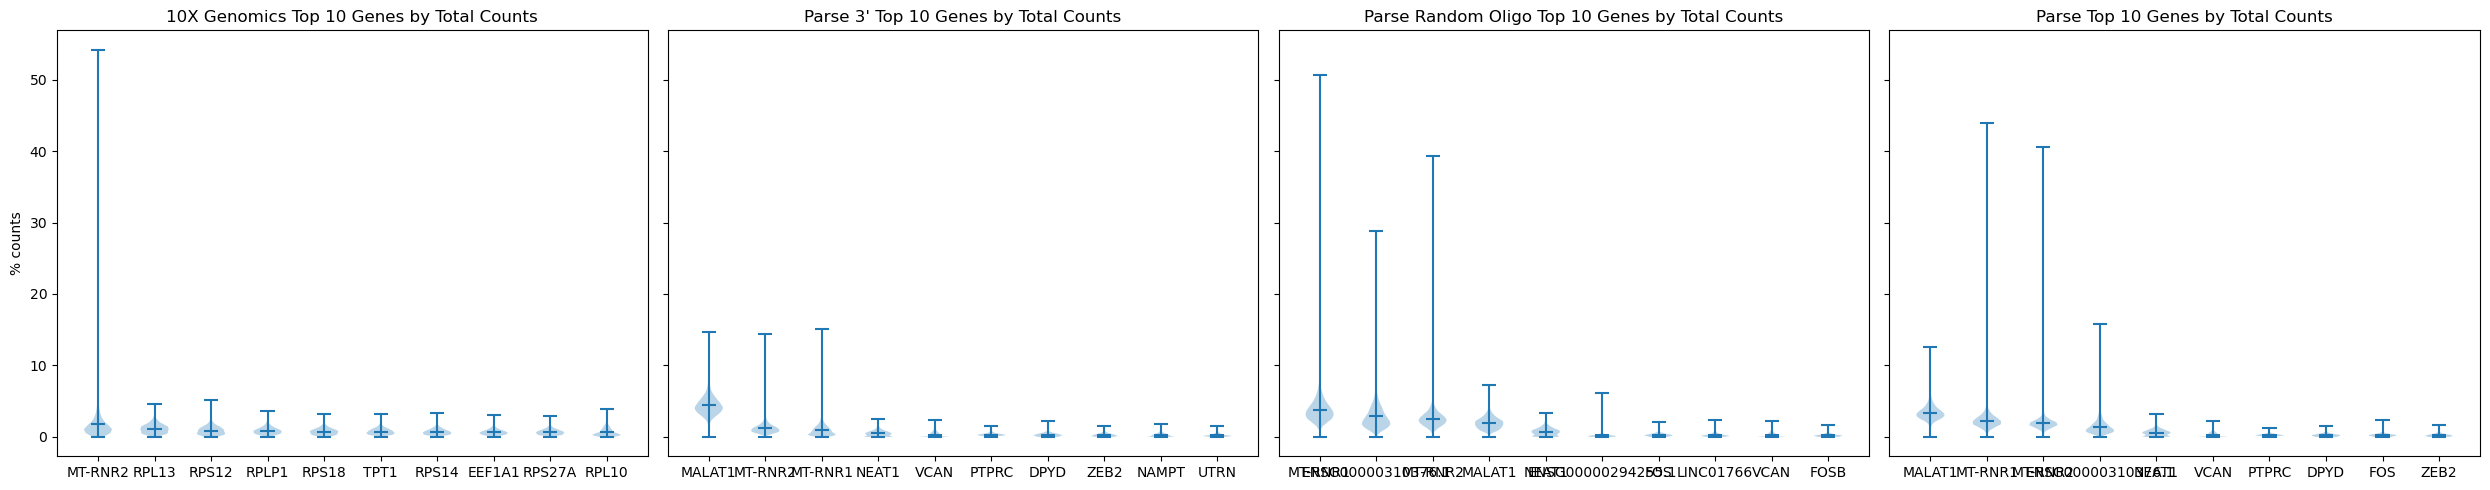

In [19]:
plotting.top_gene_counts(datasets)

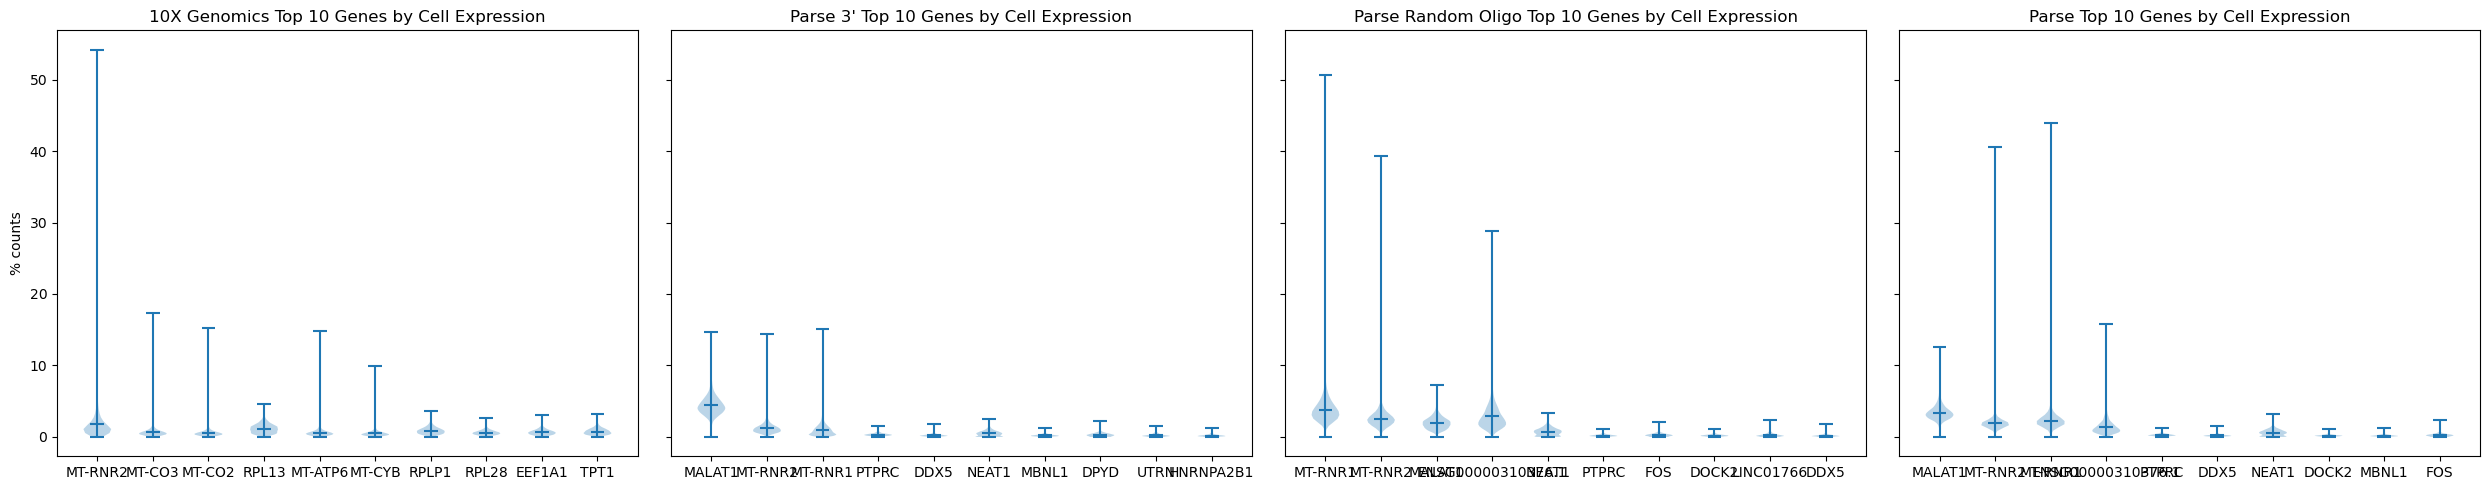

In [20]:
plotting.top_gene_cell_expression(datasets)

In [21]:
datasets[0]

AnnData object with n_obs × n_vars = 17156 × 36666
    obs: 'n_genes', 'n_counts', 'percent_nascent', 'percent_pc', 'percent_mito', 'percent_ribo', 'percent_lnc'
    var: 'gene_id', 'n_cells', 'percent_counts', 'percent_nascent', 'is_lnc', 'is_pc', 'is_mito', 'is_ribo', 'is_pseudo', 'is_oxphos', 'gene_length', 'gc_content', 'normalized_counts'
    uns: 'name', 'title', 'n_processed', 'n_aligned', 'n_unique', 'n_raw_counts', 'star_uniquely_mapped', 'star_multimapped', 'star_unmapped', 'n_genes', 'percent_nascent', 'percent_ambiguous', 'percent_mature', 'pred_upsample', 'n_raw_counts_filtered'
    layers: 'ambiguous', 'mature', 'nascent'

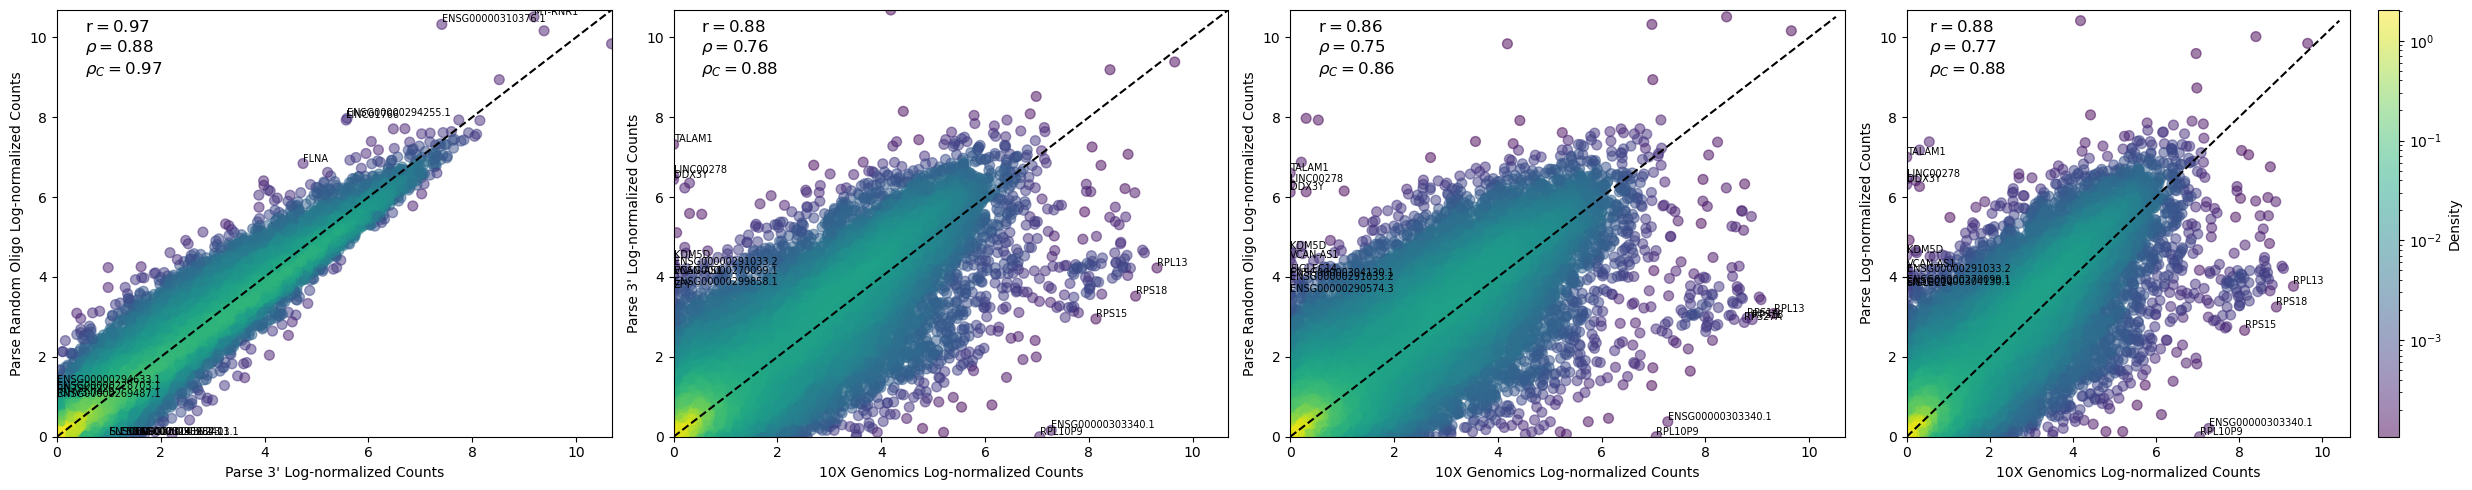

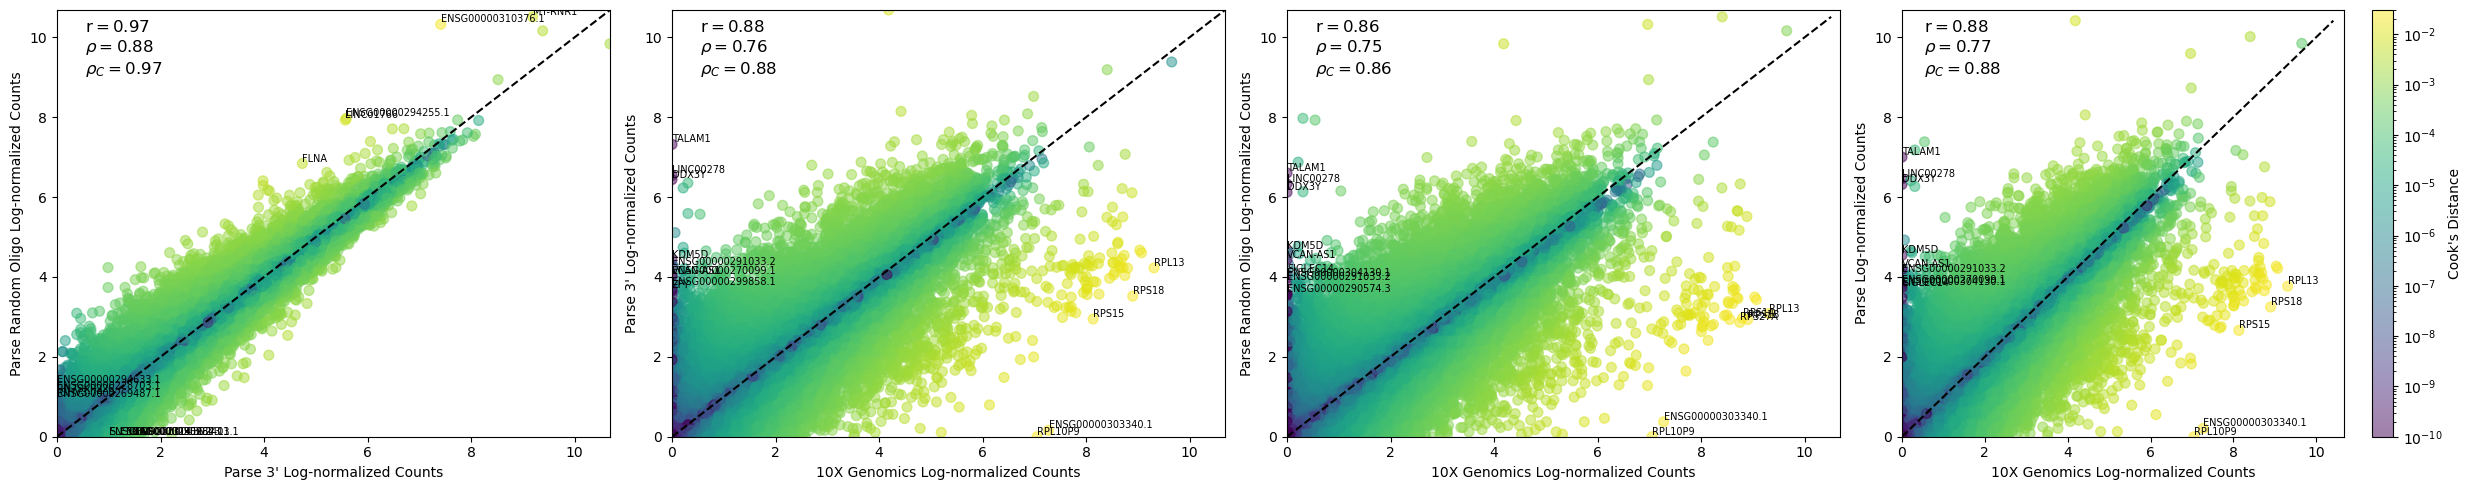

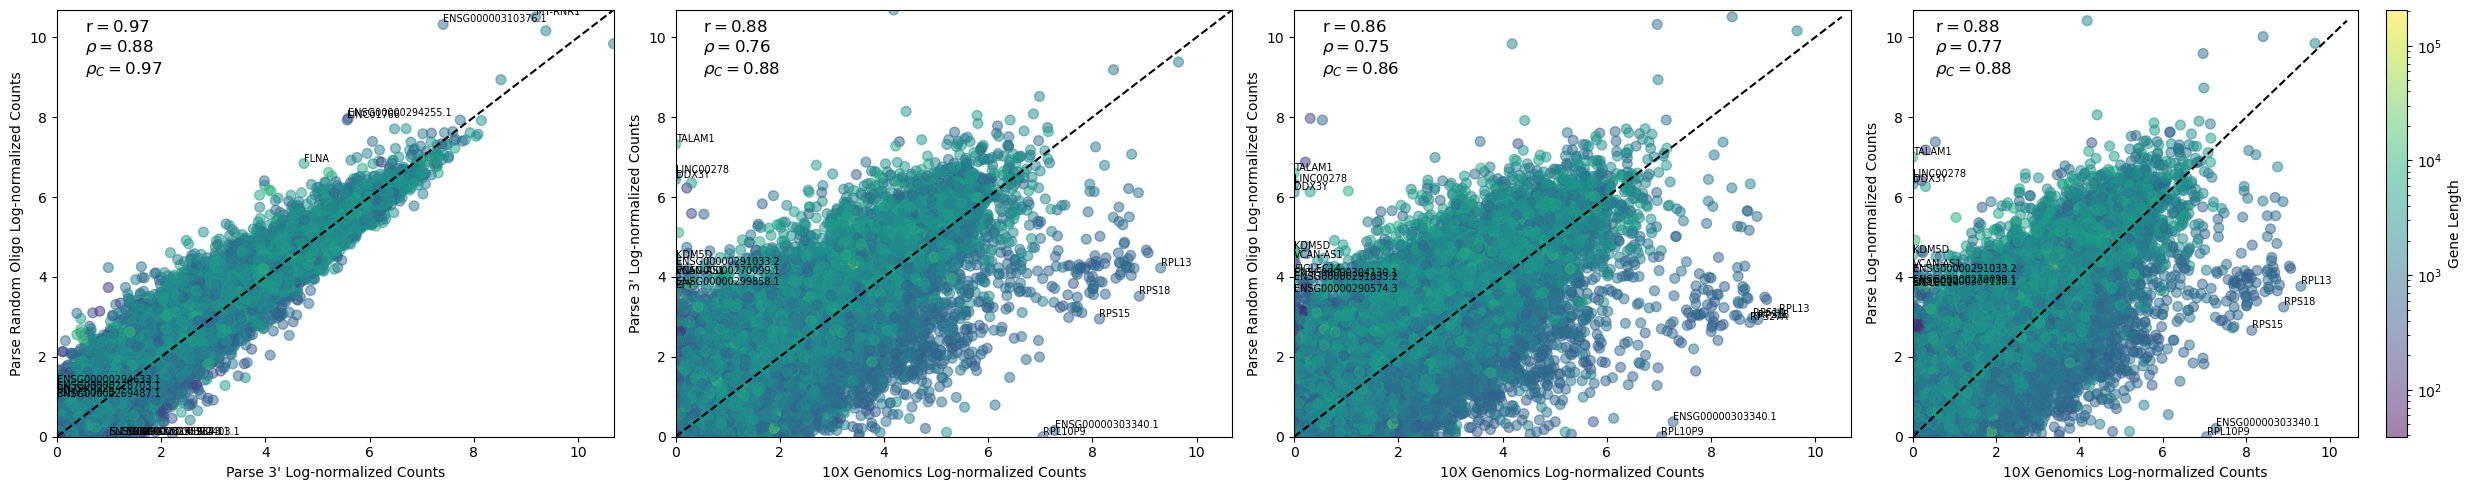

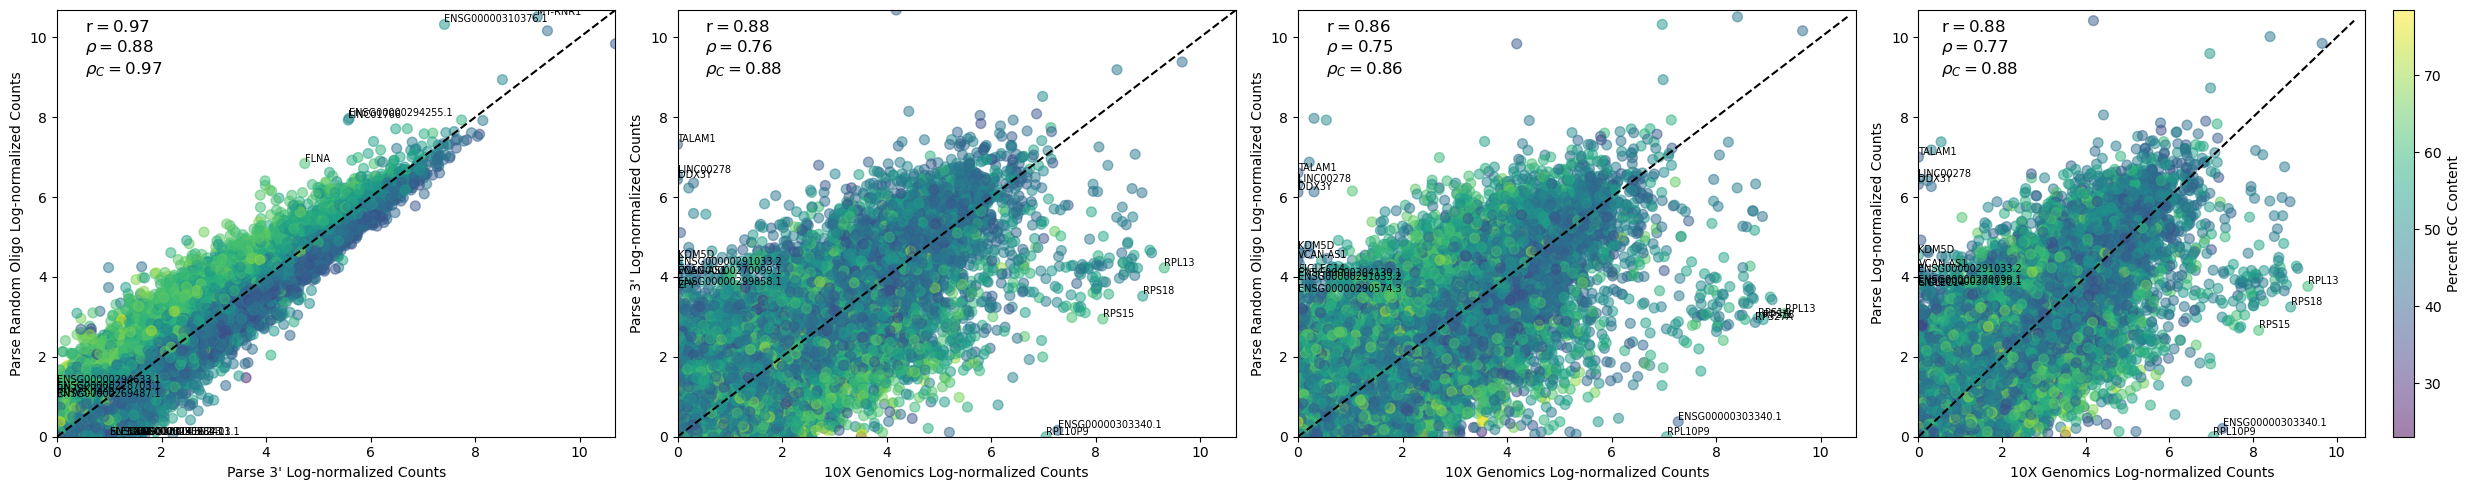

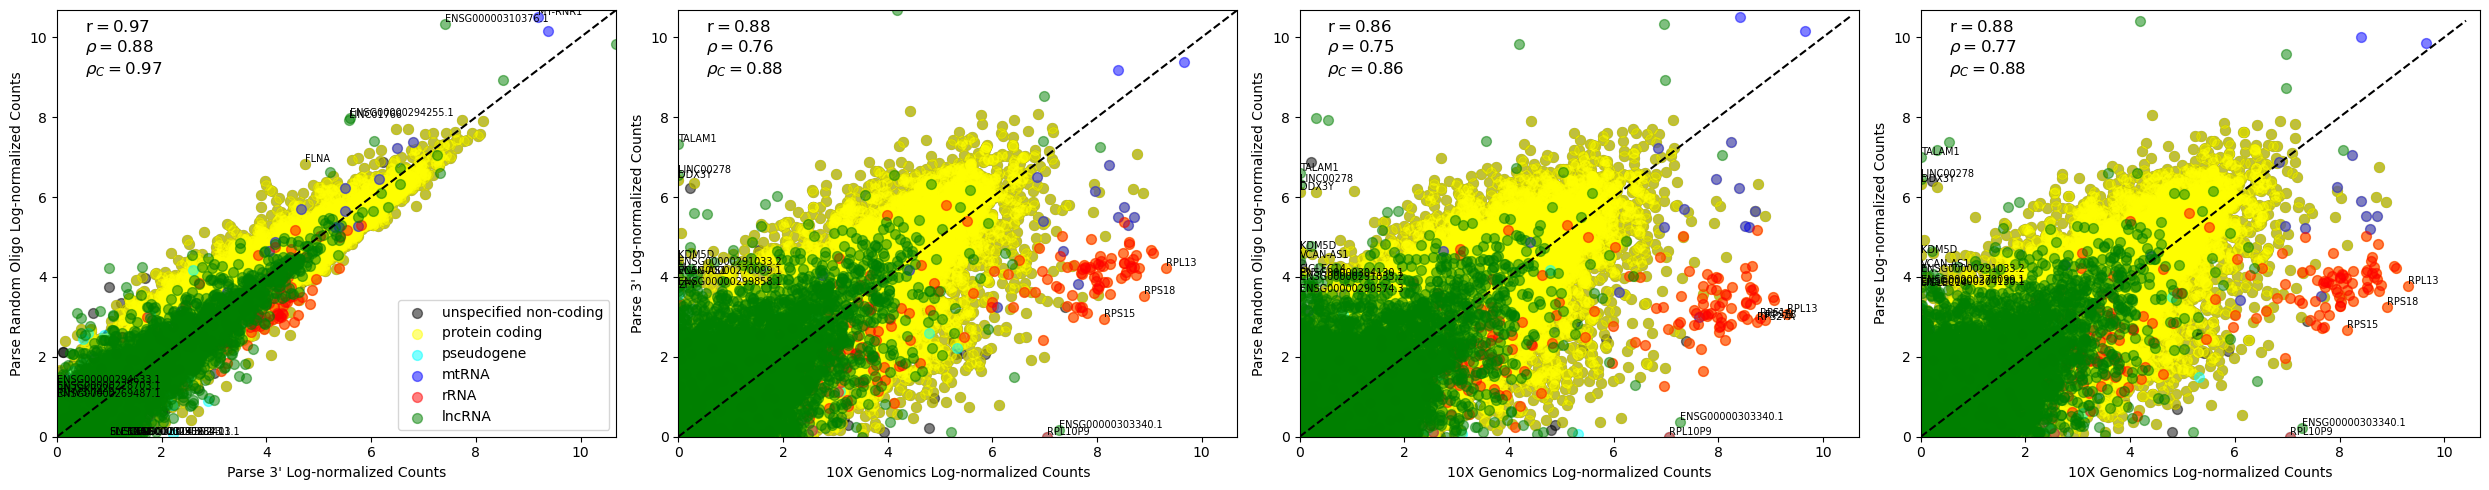

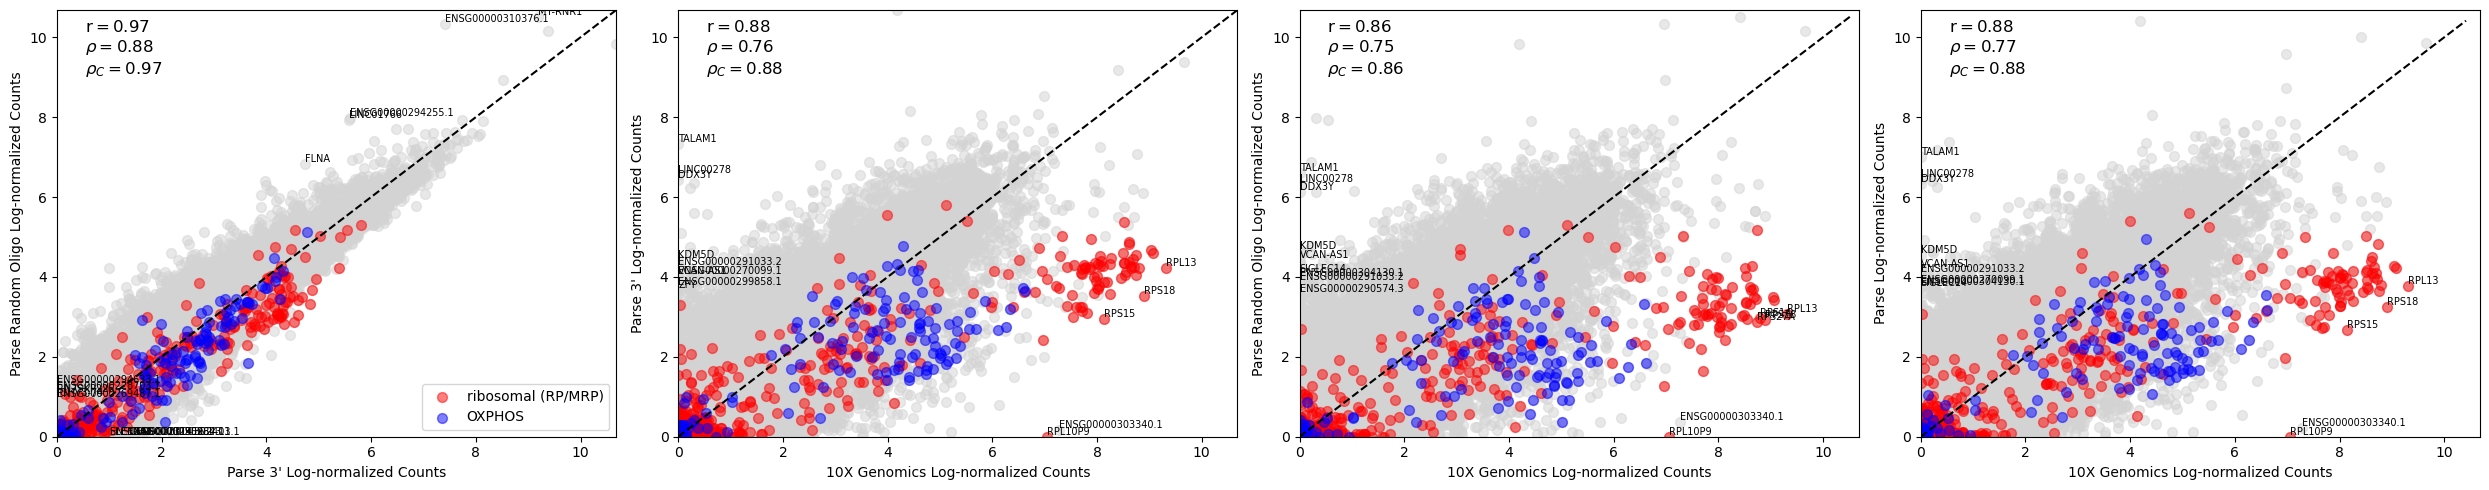

In [22]:
compare_names, compare_dfs = plotting.compare(datasets)


In [23]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)